In [6]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns

In [8]:
import pandas as pd

In [9]:
df=pd.read_csv('candidates.csv')

In [10]:
df.head(100)

,SL. NO.,State,Const No.,Constituency,Constituency Type,Total Valid Votes,Winner Name,Winner Social Category,Winner Gender,Winner Party,Winner Party Symbol,Winner Vote Secured,Runner Up Name,Runner Social Category,Runner Gender,Runner Party,Runner Party Symbol,Runner Vote Secured,Margin,Margin %
0,1,Andhra Pradesh,1.0,Araku,ST,1113975.0,GUMMA THANUJA RANI,ST,FEMALE,YSRCP,Ceiling fan,477005.0,KOTHAPALLI GEETHA,ST,FEMALE,BJP,Lotus,426425.0,50580.0,4.54
1,2,Andhra Pradesh,2.0,Srikakulam,GEN,1211081.0,KINJARAPU RAMMOHAN NAIDU,GENERAL,MALE,TDP,Bicycle,754328.0,TILAK PERADA,GENERAL,MALE,YSRCP,Ceiling fan,426427.0,327901.0,27.08
2,3,Andhra Pradesh,3.0,Vizianagaram,GEN,1275992.0,APPALANAIDU KALISETTI,GENERAL,MALE,TDP,Bicycle,743113.0,BELLANA CHANDRASEKHAR,GENERAL,MALE,YSRCP,Ceiling fan,493762.0,249351.0,19.54
3,4,Andhra Pradesh,4.0,Visakhapatnam,GEN,1381812.0,SRIBHARAT MATHUKUMILI,GENERAL,MALE,TDP,Bicycle,907467.0,JHANSI LAKSHMI. BOTCHA.,GENERAL,FEMALE,YSRCP,Ceiling fan,403220.0,504247.0,36.49
4,5,Andhra Pradesh,5.0,Anakapalle,GEN,1299097.0,C.M.RAMESH,GENERAL,MALE,BJP,Lotus,762069.0,BUDI MUTYALA NAIDU,GENERAL,MALE,YSRCP,Ceiling fan,465539.0,296530.0,22.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Gujarat,13.0,Junagadh,GEN,1054240.0,CHUDASAMA RAJESHBHAI NARANBHAI,GENERAL,MALE,BJP,Lotus,584049.0,JOTVA HIRABHAI ARJANBHAI,GENERAL,MALE,INC,Hand,448555.0,135494.0,12.85
96,97,Gujarat,14.0,Amreli,GEN,865077.0,BHARATBHAI MANUBHAI SUTARIYA,GENERAL,MALE,BJP,Lotus,580872.0,JENNY THUMMAR,GENERAL,FEMALE,INC,Hand,259804.0,321068.0,37.11
97,98,Gujarat,15.0,Bhavnagar,GEN,1028467.0,NIMUBEN JAYANTIBHAI BAMBHANIYA (NIMUBEN BAMBHA...,GENERAL,FEMALE,BJP,Lotus,716883.0,UMESHBHAI NARANBHAI MAKWANA,GENERAL,MALE,AAAP,Broom,261594.0,455289.0,44.27
98,99,Gujarat,16.0,Anand,GEN,1152039.0,MITESH PATEL (BAKABHAI),GENERAL,MALE,BJP,Lotus,612484.0,AMIT CHAVDA,GENERAL,MALE,INC,Hand,522545.0,89939.0,7.81


In [11]:
party_votes=df.groupby('Winner Party')['Winner Vote Secured'].sum().sort_values(ascending=False)

In [12]:
df.groupby(['Winner Party','Margin']).head(10).sum()

SL. NO.                   1234567891011121314151617181920212223242526272...
State                     Andhra PradeshAndhra PradeshAndhra PradeshAndh...
Const No.                                                            9847.0
Constituency              ArakuSrikakulamVizianagaramVisakhapatnamAnakap...
Constituency Type         STGENGENGENGENGENSCGENGENGENGENGENGENGENSCGENG...
Total Valid Votes                                               638990692.0
Winner Name               GUMMA THANUJA RANIKINJARAPU RAMMOHAN NAIDUAPPA...
Winner Social Category    STGENERALGENERALGENERALGENERALGENERALSCGENERAL...
Winner Gender             FEMALEMALEMALEMALEMALEMALEMALEFEMALEMALEMALEMA...
Winner Party              YSRCPTDPTDPTDPBJPJnPTDPBJPBJPTDPJnPTDPTDPTDPTD...
Winner Party Symbol       Ceiling fanBicycleBicycleBicycleLotusGlass tum...
Winner Vote Secured                                             326400045.0
Runner Up Name            KOTHAPALLI GEETHATILAK PERADABELLANA CHANDRASE...
Runner Socia

In [13]:
highest_vote_party=party_votes.idxmax()

In [14]:
lowest_vote_party=party_votes.idxmin()

In [15]:
seats_won=df['Winner Party'].value_counts()

<Axes: xlabel='Winner Party'>

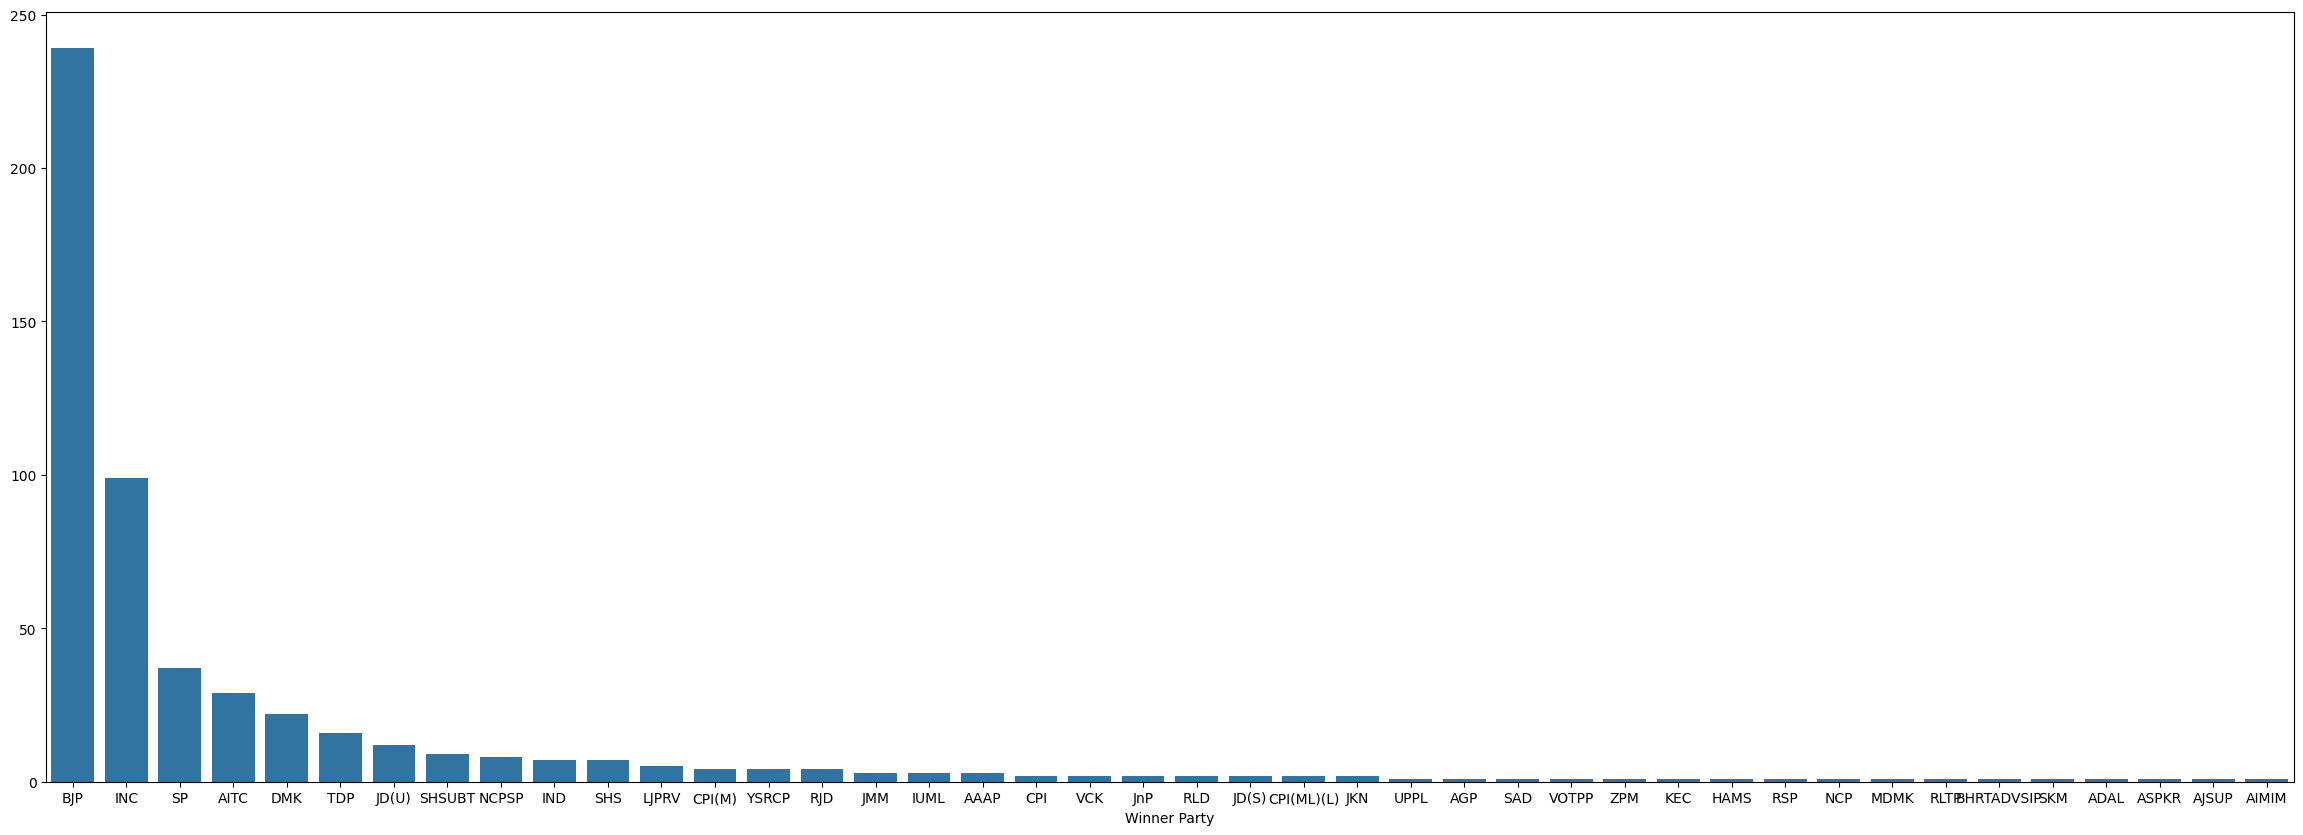

In [16]:
plt.figure(figsize=(29,10))
sns.barplot(x=seats_won.index, y=seats_won.values)

In [19]:
modi_votes=df[df['Winner Name']=='NARENDRA MODI']
rahul_votes=df[df['Winner Name']=='RAHUL GANDHI']
amit_votes=df[df['Winner Name']=='RAHUL GANDHI']

In [21]:
modi_const= modi_votes['Constituency']
rahul_const = rahul_votes['Constituency']
amit_const = amit_votes['Constituency']

In [26]:
candidates = ['RAHUL GANDHI' , 'NARENDRA MODI' , 'AMIT SHAH']

In [110]:
data_to_plot = df[df['Winner Name'].isin(candidates)].copy()

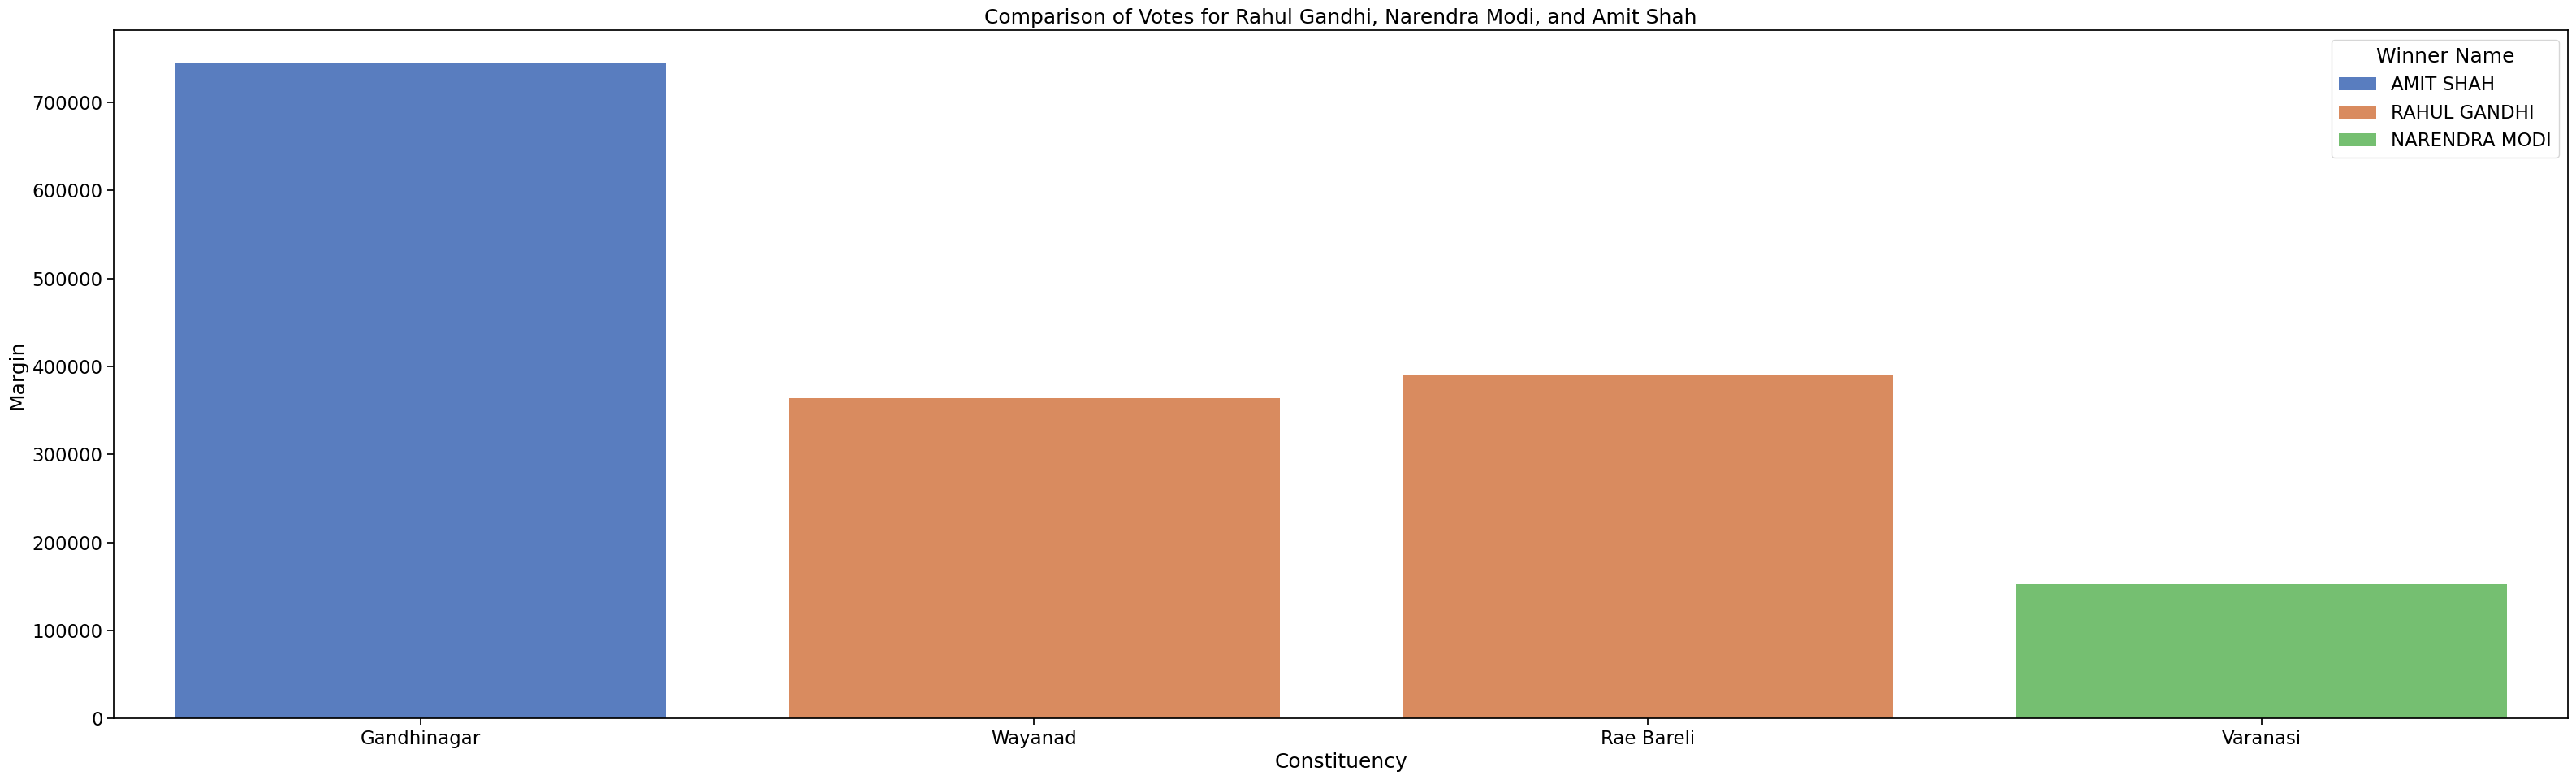

In [112]:
plt.figure(figsize=(39,11))
plt.title('Comparison of Votes for Rahul Gandhi, Narendra Modi, and Amit Shah')
sns.barplot(data = data_to_plot, x='Constituency', y='Margin', hue='Winner Name', palette='muted')
plt.ylabel='Margin'
sns.set_context("notebook", font_scale=1.5)

In [59]:
highest_margin= df.loc[df['Margin'].idxmax()]
lowest_margin = df.loc[df['Margin'].idxmin()]

Text(0.5, 1.0, 'Candidates with Highest and Lowest Margin of Victory')

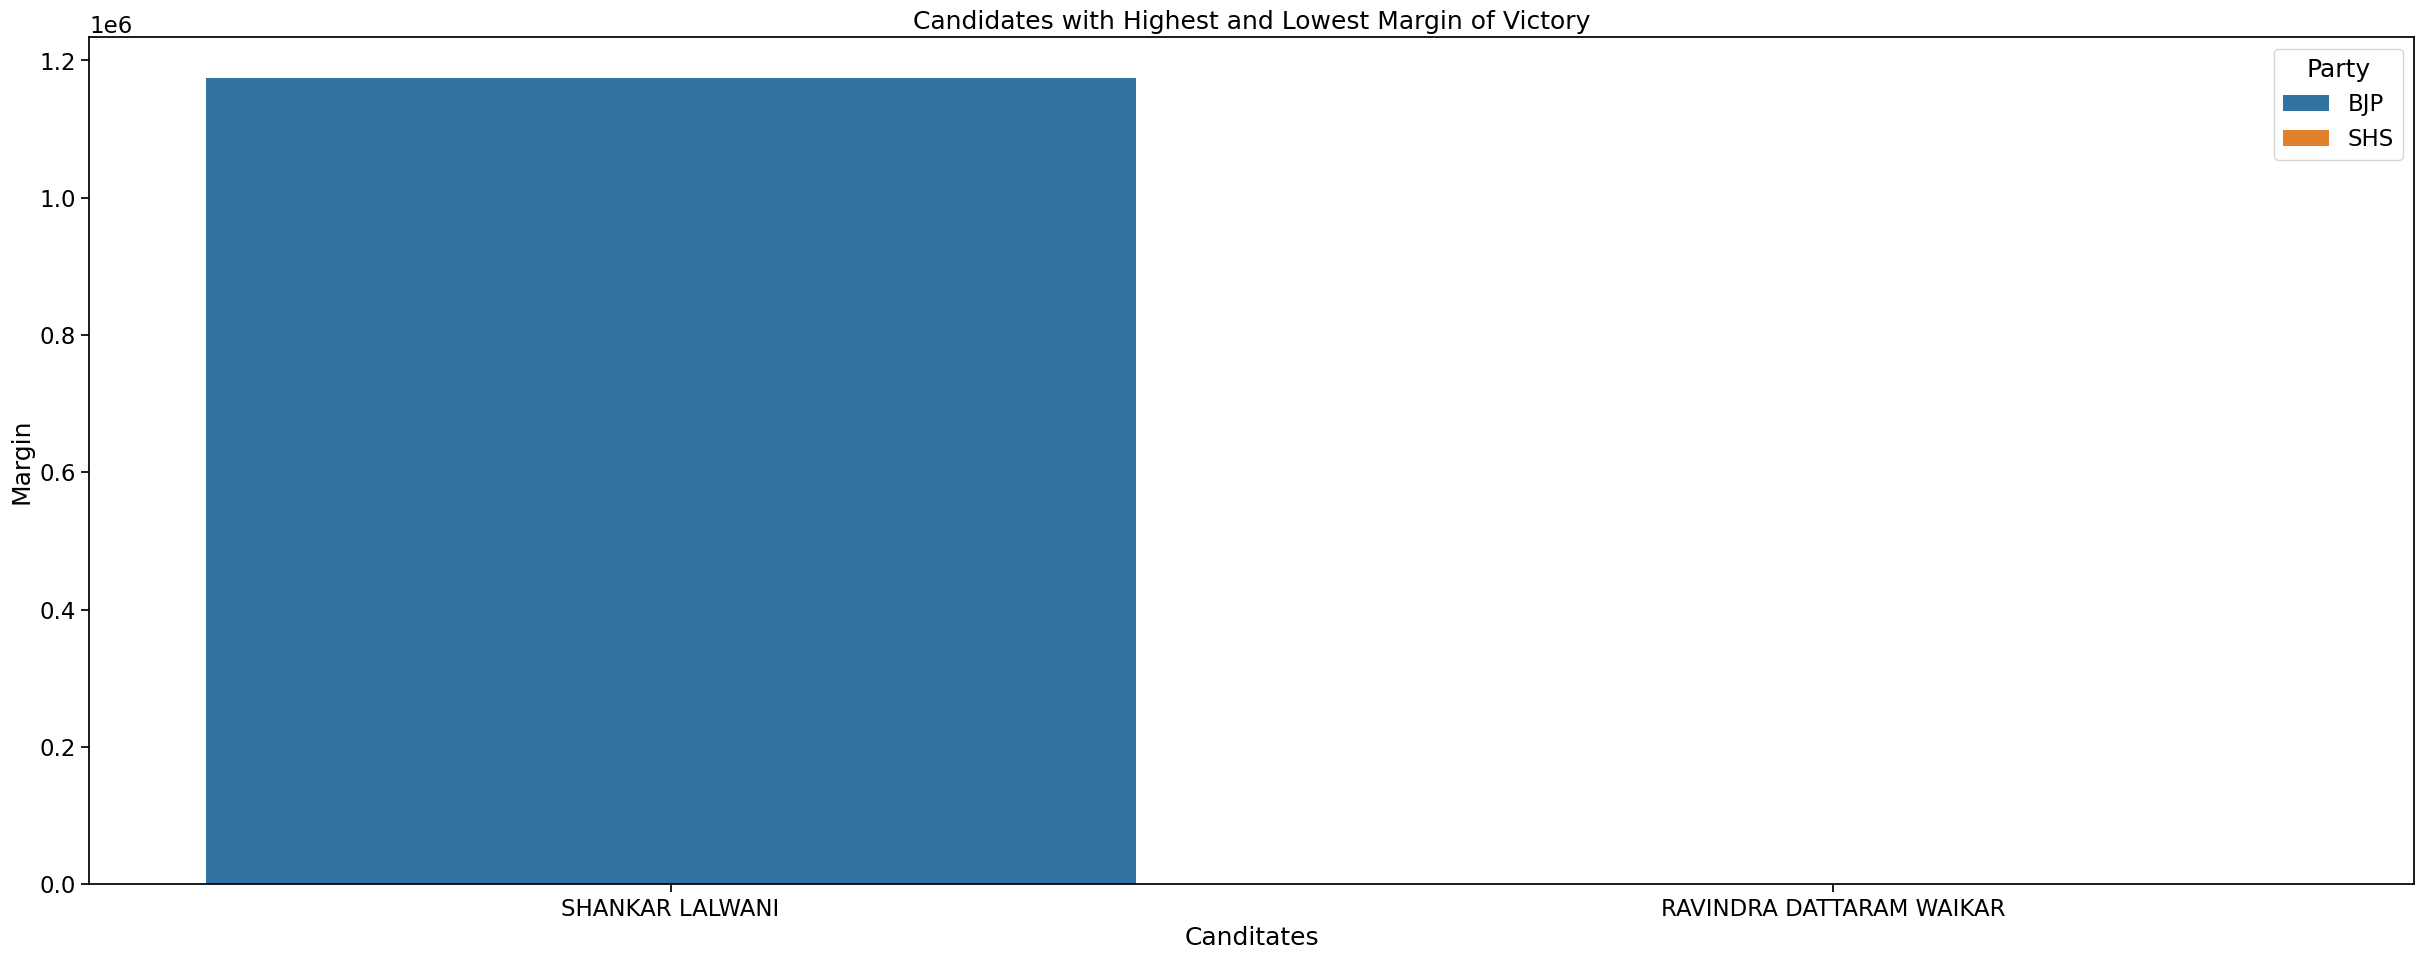

In [107]:
data_to_plot= pd.DataFrame({
    'Canditates' : [highest_margin['Winner Name'],lowest_margin['Winner Name']],
    'Party' : [highest_margin['Winner Party'], lowest_margin['Winner Party']],
    'Margin': [highest_margin['Margin'], lowest_margin['Margin']]
})

plt.figure(figsize=(30,11))
sns.barplot(data=data_to_plot,x='Canditates', y= 'Margin', hue = 'Party')
plt.title('Candidates with Highest and Lowest Margin of Victory')

<Axes: title={'center': 'Histogram of Margin of Victory'}, xlabel='Margin', ylabel='Count'>

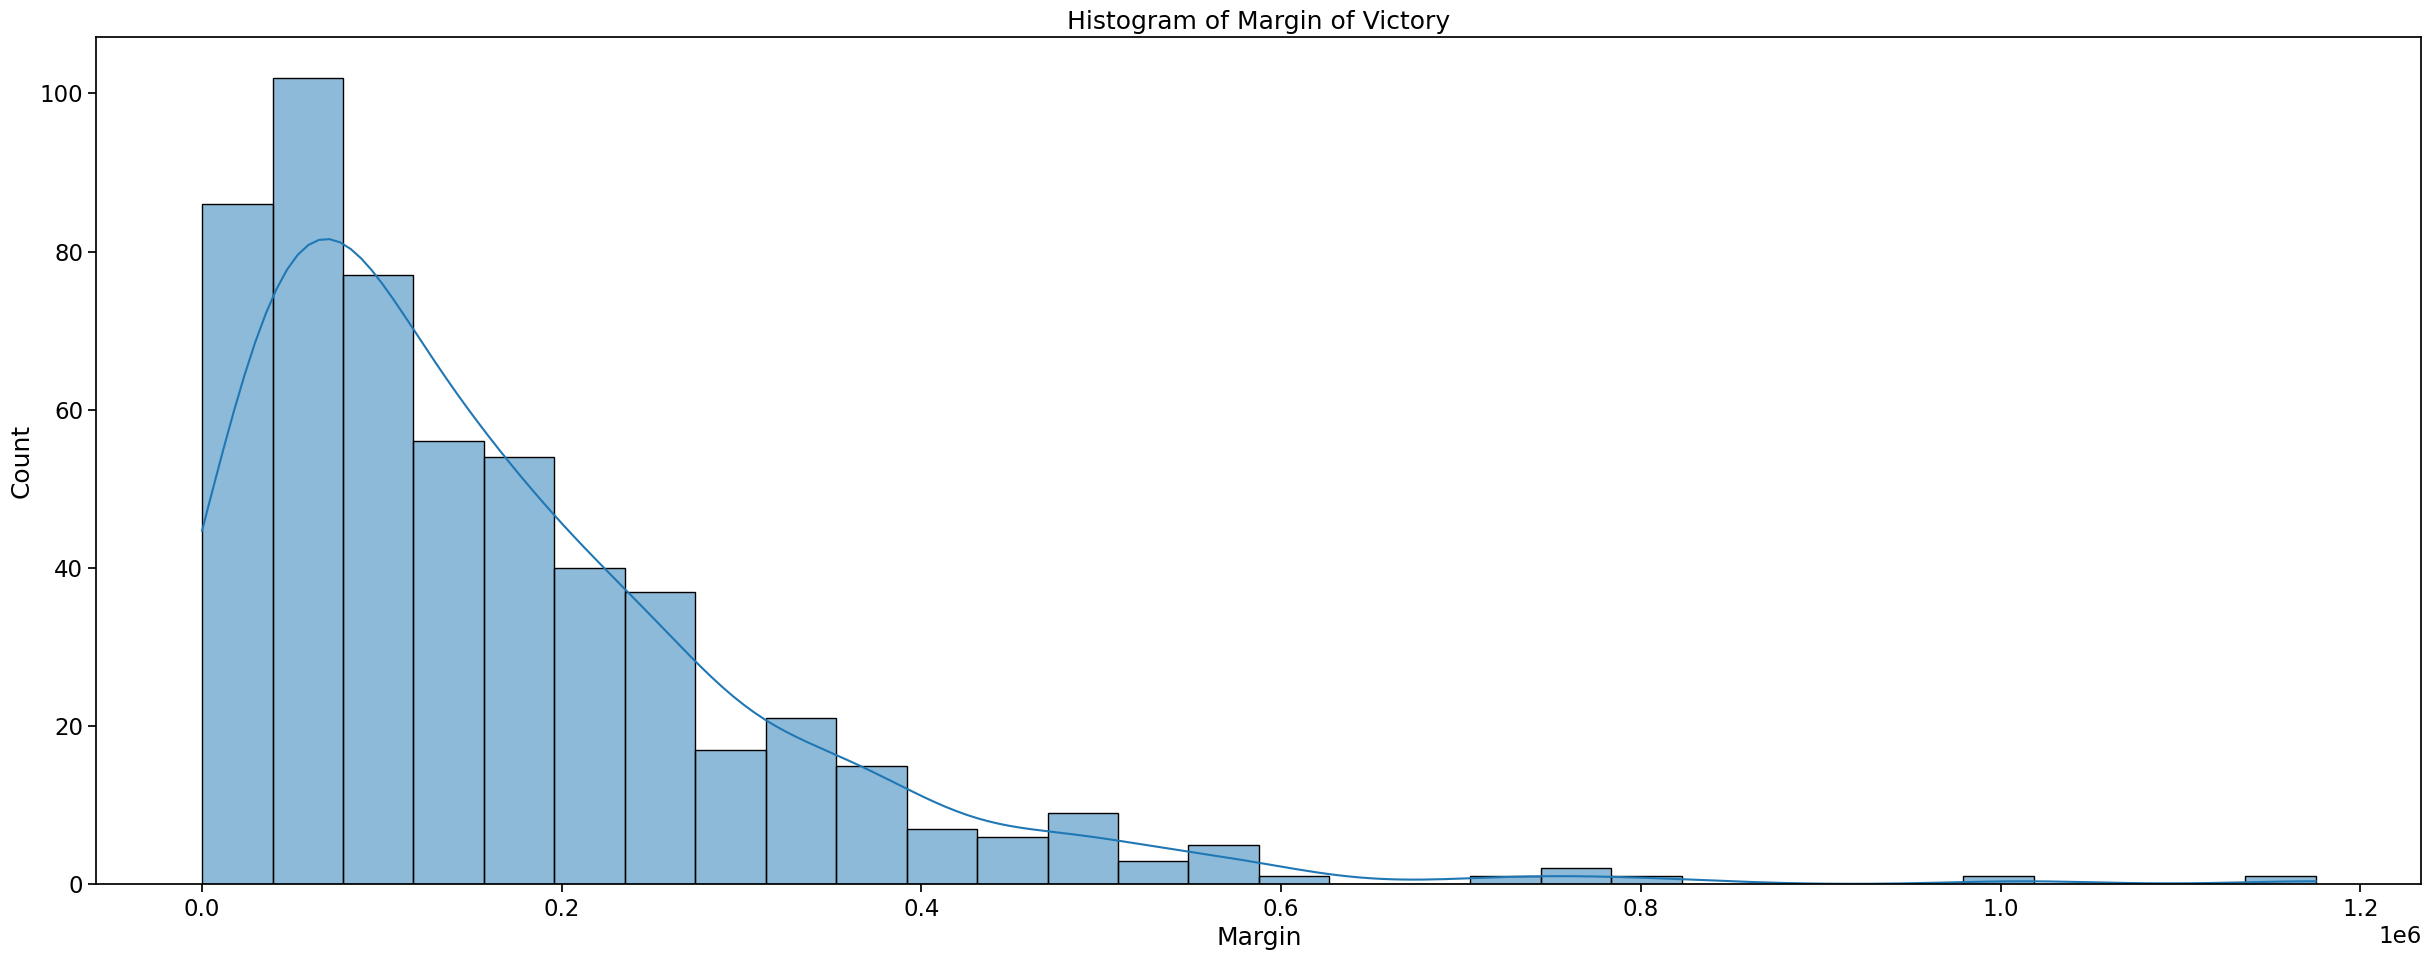

In [104]:
plt.figure(figsize=(30,11))
plt.title('Histogram of Margin of Victory')
sns.histplot(df['Margin'], kde=True)

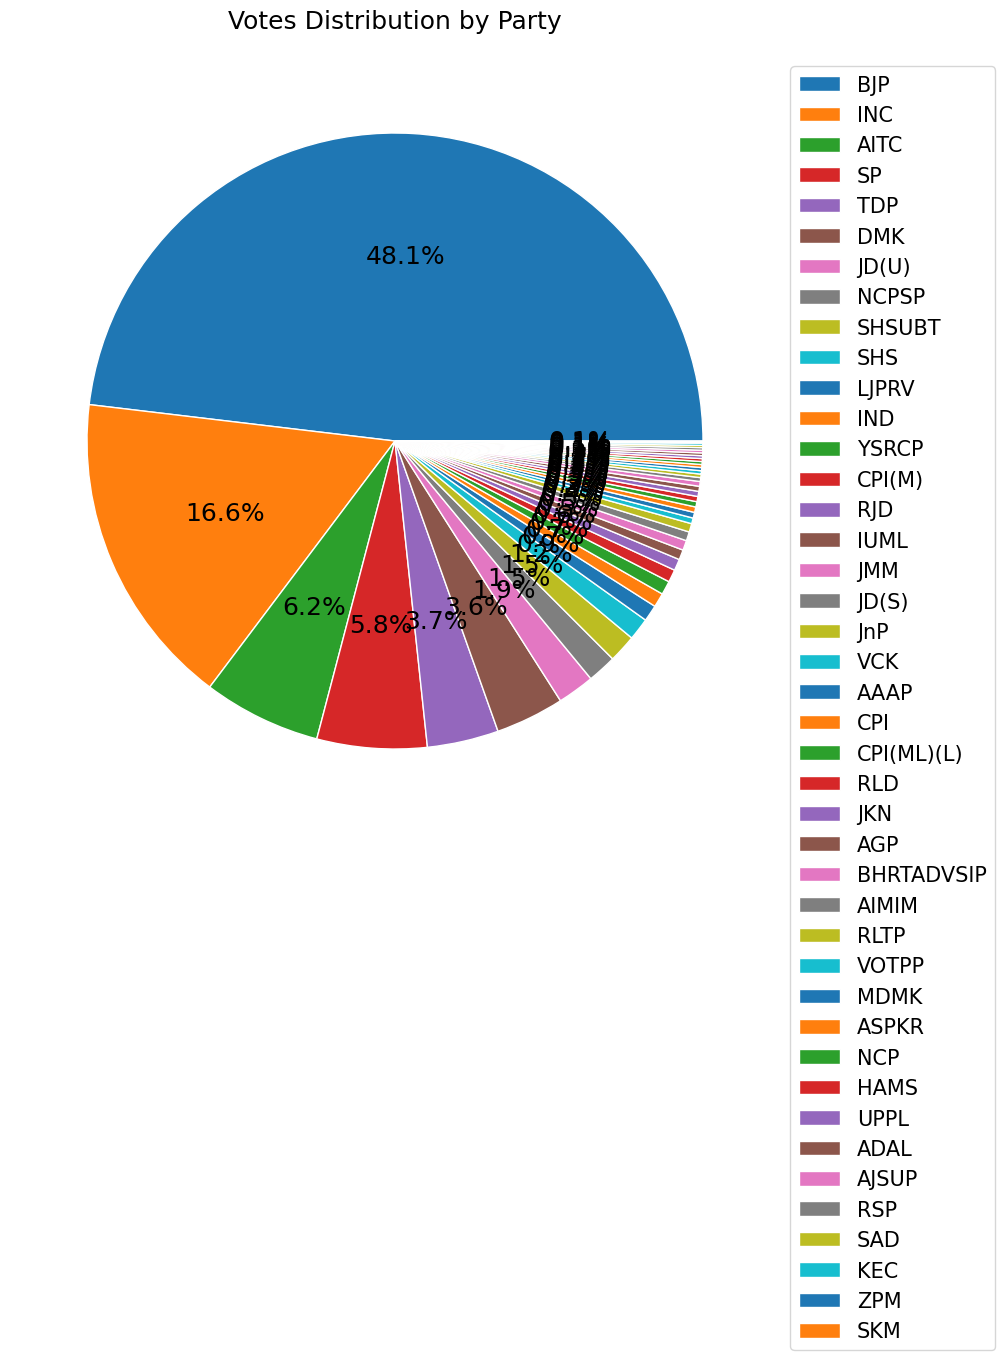

In [103]:
plt.figure(figsize=(10,10))
plt.title('Votes Distribution by Party', pad=20)
plt.pie(party_votes,labels=None, autopct='%1.1f%%', wedgeprops=dict(edgecolor='w') )
plt.legend(labels= party_votes.index,bbox_to_anchor=(1, 1), fontsize='small')

Text(0.5, 1.0, 'Top 10 Trailing Parties by Seats')

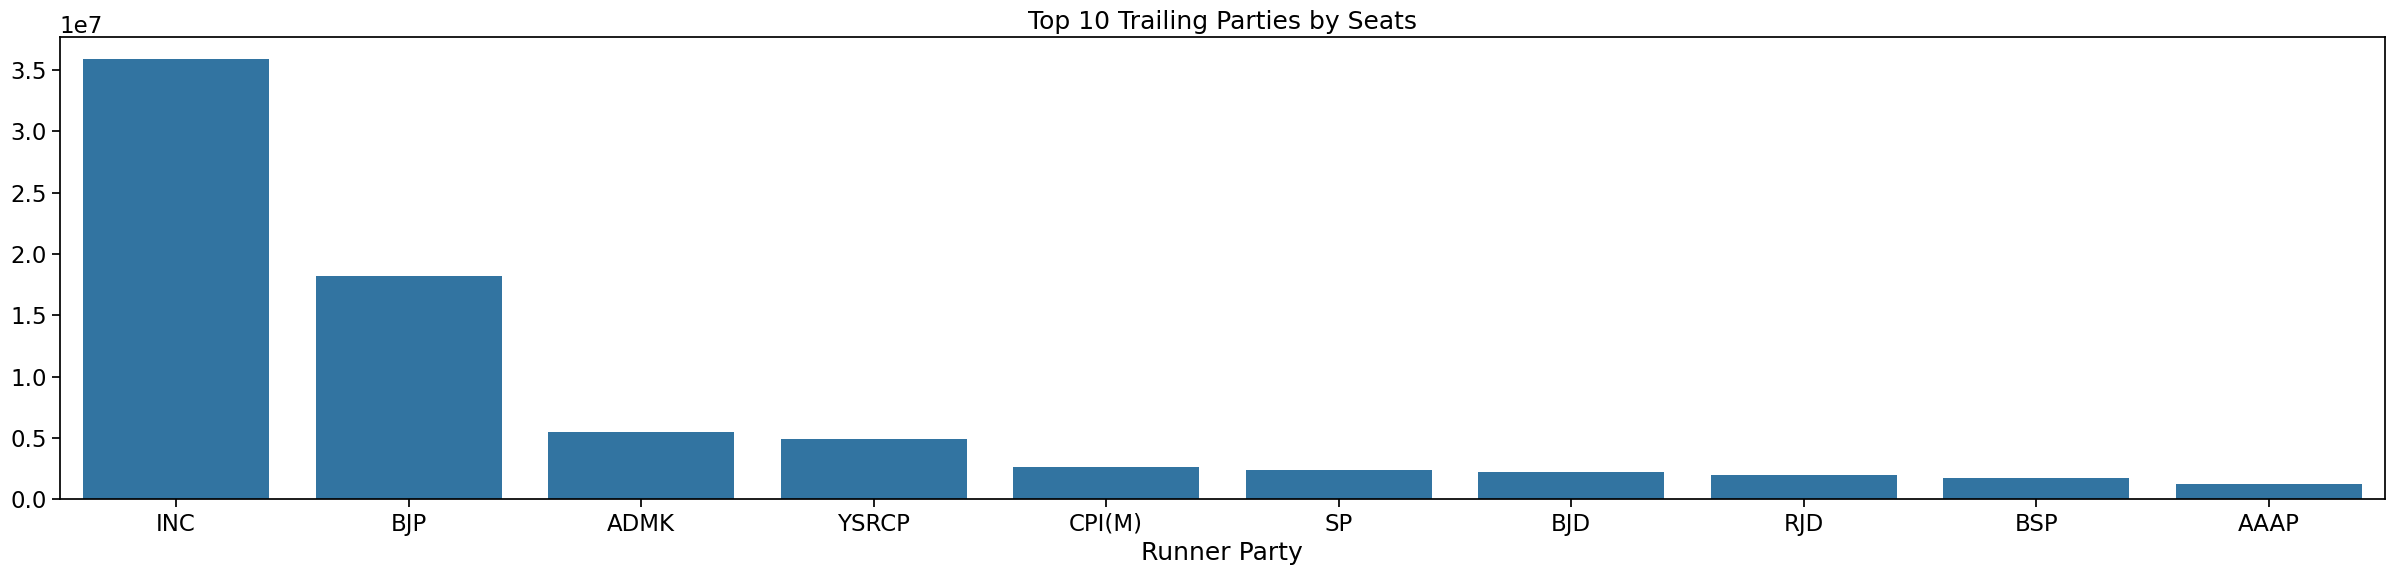

In [102]:
losing_party_votes= df.groupby('Runner Party')['Margin'].sum().sort_values(ascending=False)
plt.figure(figsize=(30,6))
sns.barplot(x=losing_party_votes.index[:10], y=losing_party_votes.values[:10])
plt.title('Top 10 Trailing Parties by Seats')